# Project 2 — Transformer Classifier

> **Transformer Mastery • Project Track**

This notebook is designed as an end-to-end, reproducible learning artifact: clear goals → implementation → experiments → diagnostics → conclusions.

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError as e:
    raise ImportError("Install PyTorch first: pip install torch") from e

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


PyTorch: 2.11.0+cpu
Device: cpu


## 1. Tiny Transformer Classifier

**Goal:** build a small Transformer encoder classifier end-to-end. The task is intentionally synthetic: classify short sequences according to whether their token pattern contains more positive than negative evidence. The point is the architecture and training workflow, not benchmark performance.

In [2]:
VOCAB   = ["<pad>", "good", "great", "excellent", "happy", "bad", "awful", "sad", "terrible"]
stoi    = {t:i for i,t in enumerate(VOCAB)}
PAD     = stoi["<pad>"]
MAX_LEN = 8

positive = {"good","great","excellent","happy"}
negative = {"bad","awful","sad","terrible"}

def make_example():
    n     = random.randint(3, MAX_LEN)
    toks  = random.choices(list(positive | negative), k=n)
    score = sum(t in positive for t in toks) - sum(t in negative for t in toks)
    label = int(score >= 0)
    ids   = [stoi[t] for t in toks] + [PAD] * (MAX_LEN - n)
    return ids, label

N     = 2400
data  = [make_example() for _ in range(N)]
random.shuffle(data)
split = int(0.8 * N)
train_data, test_data = data[:split], data[split:]

def batchify(data, bs=64):
    for i in range(0, len(data), bs):
        x = torch.tensor([a for a,b in data[i:i+bs]], dtype=torch.long)
        y = torch.tensor([b for a,b in data[i:i+bs]], dtype=torch.long)
        yield x.to(DEVICE), y.to(DEVICE)
        

print("Train:", len(train_data), "Test:", len(test_data))

Train: 1920 Test: 480


In [3]:
class TinyTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, layers=2, num_classes=2):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos_emb   = nn.Embedding(MAX_LEN, d_model)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=128,
            dropout=0.1, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h   = self.token_emb(x) + self.pos_emb(pos)
        pad_mask = x.eq(PAD)
        h      = self.encoder(h, src_key_padding_mask=pad_mask)
        valid  = (~pad_mask).unsqueeze(-1)
        pooled = (h * valid).sum(1) / valid.sum(1).clamp_min(1)
        return self.head(self.norm(pooled))

model = TinyTransformerClassifier(len(VOCAB)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()
print("Parameters:", sum(p.numel() for p in model.parameters()))


Parameters: 68290


In [4]:
def evaluate(model, data):
    model.eval()
    correct = total = loss_sum = 0.0
    with torch.no_grad():
        for x, y in batchify(data):
            logits = model(x)
            loss   = criterion(logits, y)
            loss_sum += loss.item() * len(y)
            correct  += (logits.argmax(1) == y).sum().item()
            total    += len(y)
    return loss_sum / total, correct / total

history = {
    "train_loss": [],
    "test_loss" : [],
    "test_acc"  : []
}
EPOCHS  = 20

for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_data)
    running = 0.0
    seen    = 0
    for x, y in batchify(train_data):
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(y)
        seen    += len(y)
    tr_loss = running / seen
    te_loss, te_acc = evaluate(model, test_data)
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)
    print(f"Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} | Test Loss: {te_loss:.4f} | Test Acc: {te_acc:.4f}")


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01 | Train Loss: 0.3928 | Test Loss: 0.1649 | Test Acc: 0.9563
Epoch 02 | Train Loss: 0.0959 | Test Loss: 0.0380 | Test Acc: 1.0000
Epoch 03 | Train Loss: 0.0318 | Test Loss: 0.0134 | Test Acc: 1.0000
Epoch 04 | Train Loss: 0.0163 | Test Loss: 0.0061 | Test Acc: 1.0000
Epoch 05 | Train Loss: 0.0077 | Test Loss: 0.0035 | Test Acc: 1.0000
Epoch 06 | Train Loss: 0.0047 | Test Loss: 0.0024 | Test Acc: 1.0000
Epoch 07 | Train Loss: 0.0034 | Test Loss: 0.0017 | Test Acc: 1.0000
Epoch 08 | Train Loss: 0.0031 | Test Loss: 0.0017 | Test Acc: 1.0000
Epoch 09 | Train Loss: 0.0021 | Test Loss: 0.0011 | Test Acc: 1.0000
Epoch 10 | Train Loss: 0.0020 | Test Loss: 0.0011 | Test Acc: 1.0000
Epoch 11 | Train Loss: 0.0018 | Test Loss: 0.0008 | Test Acc: 1.0000
Epoch 12 | Train Loss: 0.0012 | Test Loss: 0.0007 | Test Acc: 1.0000
Epoch 13 | Train Loss: 0.0014 | Test Loss: 0.0006 | Test Acc: 1.0000
Epoch 14 | Train Loss: 0.0015 | Test Loss: 0.0007 | Test Acc: 1.0000
Epoch 15 | Train Loss: 0.0011 | Te

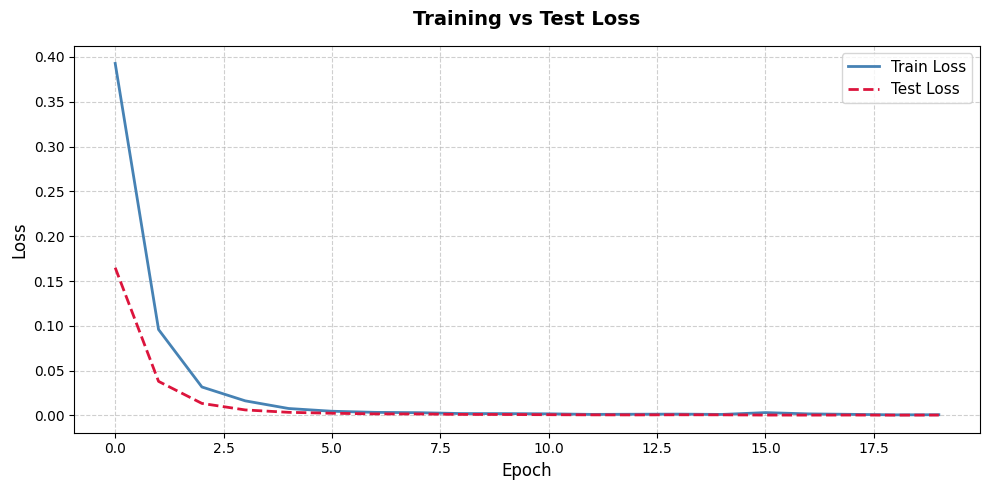

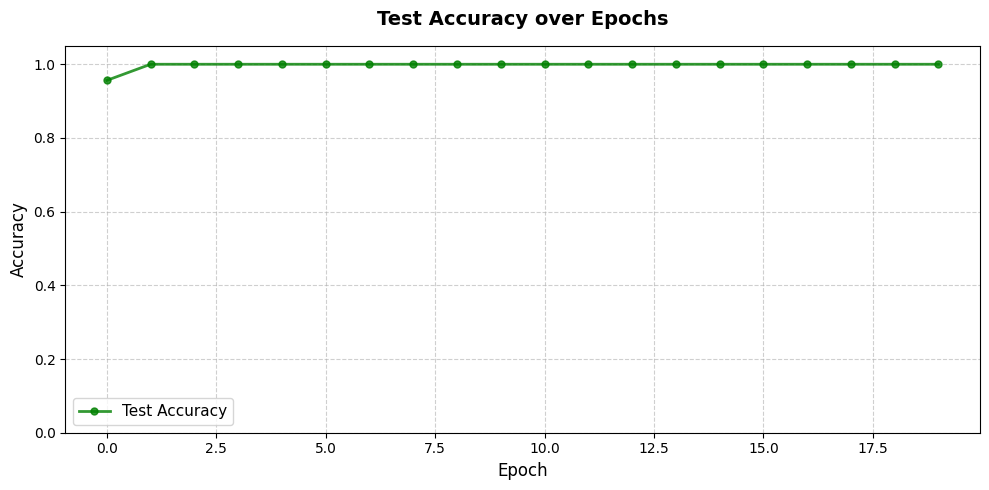

In [5]:
# Loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["train_loss"], label="Train Loss", color="steelblue", linewidth=2)
ax.plot(history["test_loss"], label="Test Loss", color="crimson", linewidth=2, linestyle="--")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training vs Test Loss", fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11, frameon=True)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Accuracy curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["test_acc"], label="Test Accuracy", marker="o", markersize=5,
        linewidth=2, color="green", alpha=0.8)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("Test Accuracy over Epochs", fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11, frameon=True)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Inference

The model is now used like a real classifier rather than only evaluated during training.

In [6]:
def predict(text):
    toks = re.findall(r"[a-z]+", text.lower())
    toks = [t for t in toks if t in stoi]
    ids  = [stoi[t] for t in toks][:MAX_LEN]
    ids += [PAD] * (MAX_LEN - len(ids))
    x    = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        probs = model(x).softmax(-1)[0]
    return {"positive": float(probs[1]), "negative": float(probs[0])}

for s in ["great happy excellent", "awful sad terrible", "good but terrible"]:
    print(s, predict(s))


great happy excellent {'positive': 0.9998832941055298, 'negative': 0.00011668388469843194}
awful sad terrible {'positive': 0.00011510117474244907, 'negative': 0.999884843826294}
good but terrible {'positive': 0.9360357522964478, 'negative': 0.06396426260471344}
